# Esame pratico Modulo 2 — Data Engineering Pipeline

Progetto finale basato sul dataset generato localmente tramite `generator.py`.

## Obiettivi
- Ingestion di file multipli con Pandas e Dask
- Pipeline ETL con PySpark
- Reporting con Matplotlib / Seaborn
- Bonus: streaming con PySpark Structured Streaming

## Nota sul dataset
La traccia richiede un'aggregazione per `payment_type`, ma il dataset generato da `generator.py` non contiene questa colonna.
Le transazioni disponibili includono invece: `transaction_id`, `customer_id`, `product_id`, `region_id`, `quantity`, `amount`, `ts`, `year`, `month`.

Per l'esercizio Dask, l'aggregazione verrà quindi eseguita su una colonna realmente presente nel dataset: `region_id`

In [57]:
from pathlib import Path
import glob
import os

import pandas as pd
import dask.dataframe as dd

BASE_DIR = Path("data_local")
PARQUET_DIR = BASE_DIR / "parquet"
JSON_DIR = BASE_DIR / "json"

print("Cartella base:", BASE_DIR.resolve())
print("File parquet:", len(list(PARQUET_DIR.glob("*.parquet"))))
print("File jsonl:", len(list(JSON_DIR.glob("*.jsonl"))))

Cartella base: /Users/francesco/Workspace/Epicode_Python_AI_ML/repos/first-project/Modulo_2_Python_Data_science/PySPARK/modulo2_esame/data_local
File parquet: 8
File jsonl: 5


In [58]:
parquet_files = sorted(PARQUET_DIR.glob("*.parquet"))
json_files = sorted(JSON_DIR.glob("*.jsonl"))

print("Primi file parquet:")
for file in parquet_files[:5]:
    print("-", file.name)

print("\nPrimi file jsonl:")
for file in json_files[:5]:
    print("-", file.name)

Primi file parquet:
- customers.parquet
- products.parquet
- regions.parquet
- transactions_batch_0000.parquet
- transactions_batch_0001.parquet

Primi file jsonl:
- transactions_part_0000.jsonl
- transactions_part_0001.jsonl
- transactions_part_0002.jsonl
- transactions_part_0003.jsonl
- transactions_part_0004.jsonl


In [59]:
sample_json = pd.read_json(json_files[0], lines=True)

print("Shape file campione:", sample_json.shape)
print("\nColonne:")
print(sample_json.columns.tolist())

sample_json.head()

Shape file campione: (100000, 9)

Colonne:
['transaction_id', 'customer_id', 'product_id', 'region_id', 'quantity', 'amount', 'ts', 'year', 'month']


,transaction_id,customer_id,product_id,region_id,quantity,amount,ts,year,month
0,5bc9c52f-4c97-42ad-ab30-9883399a18ac,16676,2337,2,1,60.130001,2020-08-31,2020,8
1,133aae84-94f7-43e5-b697-c5aedbb4a362,33111,3963,1,1,18.030001,2020-12-06,2020,12
2,a0f07d81-6eef-44d1-a419-58f691434830,9831,175,1,4,47.919998,2022-04-04,2022,4
3,96037256-4891-414b-bdc6-bd90d1e848eb,28516,4459,1,4,229.600006,2020-09-30,2020,9
4,a2a09db4-d40e-49e1-9b5b-50c5182727b3,2362,3713,4,5,44.650002,2021-03-31,2021,3


In [60]:
sample_json.dtypes

transaction_id     object
customer_id         int64
product_id          int64
region_id           int64
quantity            int64
amount            float64
ts                 object
year                int64
month               int64
dtype: object

## Esercizio 1A — Ingestion con Pandas
Lettura sequenziale dei file JSONL per contenere l'uso della memoria e calcolo del totale generale della colonna `amount`.

In [61]:
def somma_amount_con_pandas(file_list):
    """
    Legge i file JSONL uno alla volta con Pandas, calcola la somma
    della colonna 'amount' per ciascun file e restituisce il totale generale.

    Parameters
    ----------
    file_list : list[Path]
        Lista dei file JSONL da elaborare.

    Returns
    -------
    float
        Somma totale della colonna 'amount' su tutti i file.
    """
    totale_generale = 0.0

    for file_path in file_list:
        df = pd.read_json(file_path, lines=True)
        totale_file = df["amount"].sum()
        totale_generale += totale_file

        print(f"{file_path.name}: totale amount = {totale_file:.2f}")

    return totale_generale

In [62]:
totale_amount_pandas = somma_amount_con_pandas(json_files)

print("\nTotale generale amount (Pandas):", round(totale_amount_pandas, 2))

transactions_part_0000.jsonl: totale amount = 9815541.99
transactions_part_0001.jsonl: totale amount = 9783011.98
transactions_part_0002.jsonl: totale amount = 9820215.26
transactions_part_0003.jsonl: totale amount = 9815461.27
transactions_part_0004.jsonl: totale amount = 9794082.15

Totale generale amount (Pandas): 49028312.65


## Esercizio 1B — Ingestion con Dask
Lettura di tutti i file JSONL con wildcard e calcolo della media degli importi raggruppati per `region_id`.

In [63]:
dask_df = dd.read_json(str(JSON_DIR / "*.jsonl"), lines=True)

print("Colonne Dask:")
print(dask_df.columns.tolist())

Colonne Dask:
['transaction_id', 'customer_id', 'product_id', 'region_id', 'quantity', 'amount', 'ts', 'year', 'month']


In [64]:
media_amount_per_regione = (
    dask_df.groupby("region_id")["amount"]
    .mean()
    .compute()
    .sort_index()
    .rename("avg_amount")
)

print("Media amount per region_id:")
print(media_amount_per_regione)

Media amount per region_id:
region_id
1    98.338746
2    98.103429
3    97.441572
4    98.406569
5    97.997947
Name: avg_amount, dtype: float64


In [65]:
print("Totale file JSONL letti:", len(json_files))
print("Numero regioni aggregate con Dask:", media_amount_per_regione.shape[0])

Totale file JSONL letti: 5
Numero regioni aggregate con Dask: 5


## Esercizio 2 — Pipeline ETL con PySpark

In questo esercizio viene costruita una pipeline ETL su Spark:

- **Extract**: caricamento delle tabelle Parquet
- **Transform**: join tra transazioni, prodotti e regioni
- **Load**: salvataggio del risultato finale in formato Parquet partizionato per `year`

Il DataFrame finale deve contenere le colonne:
`transaction_id`, `region_name`, `category`, `amount`, `year`

In [66]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [67]:
def crea_spark_session(app_name="Esame_Modulo2_Data_Engineering"):
    """
    Crea e restituisce una SparkSession locale per l'esecuzione
    della pipeline ETL del progetto.

    Parameters
    ----------
    app_name : str
        Nome dell'applicazione Spark.

    Returns
    -------
    SparkSession
        Sessione Spark attiva.
    """
    spark = (
        SparkSession.builder
        .appName(app_name)
        .master("local[*]")
        .getOrCreate()
    )
    return spark

In [68]:
spark = crea_spark_session()
print("Spark version:", spark.version)

Spark version: 4.1.1


In [69]:
transactions_json_path = str(JSON_DIR / "*.jsonl")
products_path = str(PARQUET_DIR / "products.parquet")
regions_path = str(PARQUET_DIR / "regions.parquet")

transactions_df = spark.read.json(transactions_json_path)
products_df = spark.read.parquet(products_path)
regions_df = spark.read.parquet(regions_path)

26/03/11 11:36:31 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: data_local/json/*.jsonl.
java.io.FileNotFoundException: File data_local/json/*.jsonl does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:143)
	at org.apache.spark.sql.catalyst.analysis

In [70]:
print("Colonne transazioni:", transactions_df.columns)
print("Colonne prodotti:", products_df.columns)
print("Colonne regioni:", regions_df.columns)

transactions_df.printSchema()
products_df.printSchema()
regions_df.printSchema()

Colonne transazioni: ['amount', 'customer_id', 'month', 'product_id', 'quantity', 'region_id', 'transaction_id', 'ts', 'year']
Colonne prodotti: ['product_id', 'category', 'price']
Colonne regioni: ['region_id', 'region_name']
root
 |-- amount: double (nullable = true)
 |-- customer_id: long (nullable = true)
 |-- month: long (nullable = true)
 |-- product_id: long (nullable = true)
 |-- quantity: long (nullable = true)
 |-- region_id: long (nullable = true)
 |-- transaction_id: string (nullable = true)
 |-- ts: string (nullable = true)
 |-- year: long (nullable = true)

root
 |-- product_id: integer (nullable = true)
 |-- category: string (nullable = true)
 |-- price: float (nullable = true)

root
 |-- region_id: long (nullable = true)
 |-- region_name: string (nullable = true)



In [71]:
transactions_df.show(5, truncate=False)
products_df.show(5, truncate=False)
regions_df.show(5, truncate=False)

+--------------+-----------+-----+----------+--------+---------+------------------------------------+----------+----+
|amount        |customer_id|month|product_id|quantity|region_id|transaction_id                      |ts        |year|
+--------------+-----------+-----+----------+--------+---------+------------------------------------+----------+----+
|60.1300010681 |16676      |8    |2337      |1       |2        |5bc9c52f-4c97-42ad-ab30-9883399a18ac|2020-08-31|2020|
|18.0300006866 |33111      |12   |3963      |1       |1        |133aae84-94f7-43e5-b697-c5aedbb4a362|2020-12-06|2020|
|47.9199981689 |9831       |4    |175       |4       |1        |a0f07d81-6eef-44d1-a419-58f691434830|2022-04-04|2022|
|229.6000061035|28516      |9    |4459      |4       |1        |96037256-4891-414b-bdc6-bd90d1e848eb|2020-09-30|2020|
|44.6500015259 |2362       |3    |3713      |5       |4        |a2a09db4-d40e-49e1-9b5b-50c5182727b3|2021-03-31|2021|
+--------------+-----------+-----+----------+--------+--

### Transform
Le transazioni vengono arricchite con:

- la `category` dai prodotti, tramite join su `product_id`
- il `region_name` dalle regioni, tramite join su `region_id`

Dal risultato vengono poi selezionate solo le colonne richieste dalla traccia.

In [72]:
clean_sales_df = (
    transactions_df.alias("t")
    .join(
        products_df.select("product_id", "category").alias("p"),
        on="product_id",
        how="left"
    )
    .join(
        regions_df.select("region_id", "region_name").alias("r"),
        on="region_id",
        how="left"
    )
    .select(
        F.col("t.transaction_id").alias("transaction_id"),
        F.col("r.region_name").alias("region_name"),
        F.col("p.category").alias("category"),
        F.col("t.amount").alias("amount"),
        F.col("t.year").alias("year")
    )
)

In [73]:
clean_sales_df.printSchema()
clean_sales_df.show(10, truncate=False)

root
 |-- transaction_id: string (nullable = true)
 |-- region_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- year: long (nullable = true)

+------------------------------------+-----------+-----------+--------------+----+
|transaction_id                      |region_name|category   |amount        |year|
+------------------------------------+-----------+-----------+--------------+----+
|5bc9c52f-4c97-42ad-ab30-9883399a18ac|South      |Books      |60.1300010681 |2020|
|133aae84-94f7-43e5-b697-c5aedbb4a362|North      |Home       |18.0300006866 |2020|
|a0f07d81-6eef-44d1-a419-58f691434830|North      |Home       |47.9199981689 |2022|
|96037256-4891-414b-bdc6-bd90d1e848eb|North      |Electronics|229.6000061035|2020|
|a2a09db4-d40e-49e1-9b5b-50c5182727b3|West       |Home       |44.6500015259 |2021|
|5258edf7-d371-4c65-8ee1-d9261345b536|East       |Beauty     |20.5999984741 |2022|
|b771f18a-7c36-4137-8c75-f740fd95fe3c|South   

In [74]:
clean_sales_df.select(
    F.count("*").alias("rows_total"),
    F.count("transaction_id").alias("transaction_id_non_null"),
    F.count("region_name").alias("region_name_non_null"),
    F.count("category").alias("category_non_null"),
    F.count("amount").alias("amount_non_null"),
    F.count("year").alias("year_non_null")
).show()

+----------+-----------------------+--------------------+-----------------+---------------+-------------+
|rows_total|transaction_id_non_null|region_name_non_null|category_non_null|amount_non_null|year_non_null|
+----------+-----------------------+--------------------+-----------------+---------------+-------------+
|    500000|                 500000|              500000|           500000|         500000|       500000|
+----------+-----------------------+--------------------+-----------------+---------------+-------------+



### Load
Il dataset finale viene salvato nella cartella `data_local/processed_sales`
in formato Parquet, con partizionamento per `year`.

In [75]:
PROCESSED_DIR = BASE_DIR / "processed_sales"

(
    clean_sales_df.write
    .mode("overwrite")
    .partitionBy("year")
    .parquet(str(PROCESSED_DIR))
)

print("Dataset processato salvato in:", PROCESSED_DIR.resolve())

Dataset processato salvato in: /Users/francesco/Workspace/Epicode_Python_AI_ML/repos/first-project/Modulo_2_Python_Data_science/PySPARK/modulo2_esame/data_local/processed_sales


In [76]:
sorted([p.name for p in PROCESSED_DIR.glob("*")])

['._SUCCESS.crc', '_SUCCESS', 'year=2020', 'year=2021', 'year=2022']

## Esercizio 3 — Data Visualization (Reporting)

A partire dal DataFrame Spark pulito creato nell'Esercizio 2, viene calcolato il fatturato totale per categoria.

Poiché il risultato aggregato contiene poche righe, viene convertito in Pandas tramite `.toPandas()` e poi rappresentato con un grafico a barre usando Matplotlib e Seaborn.

In [77]:
revenue_by_category_spark = (
    clean_sales_df.groupBy("category")
    .agg(F.sum("amount").alias("total_revenue"))
    .orderBy(F.desc("total_revenue"))
)

revenue_by_category_spark.show(truncate=False)

+-----------+-----------------+
|category   |total_revenue    |
+-----------+-----------------+
|Electronics|9191426.73204712 |
|Beauty     |8764821.450474722|
|Toys       |8250915.579415696|
|Home       |7879555.020705623|
|Books      |7649505.768425039|
|Clothing   |7292088.099636888|
+-----------+-----------------+



In [78]:
revenue_by_category_pd = revenue_by_category_spark.toPandas()
revenue_by_category_pd

,category,total_revenue
0,Electronics,9.191427e+06
1,Beauty,8.764821e+06
2,Toys,8.250916e+06
3,Home,7.879555e+06
4,Books,7.649506e+06
5,Clothing,7.292088e+06


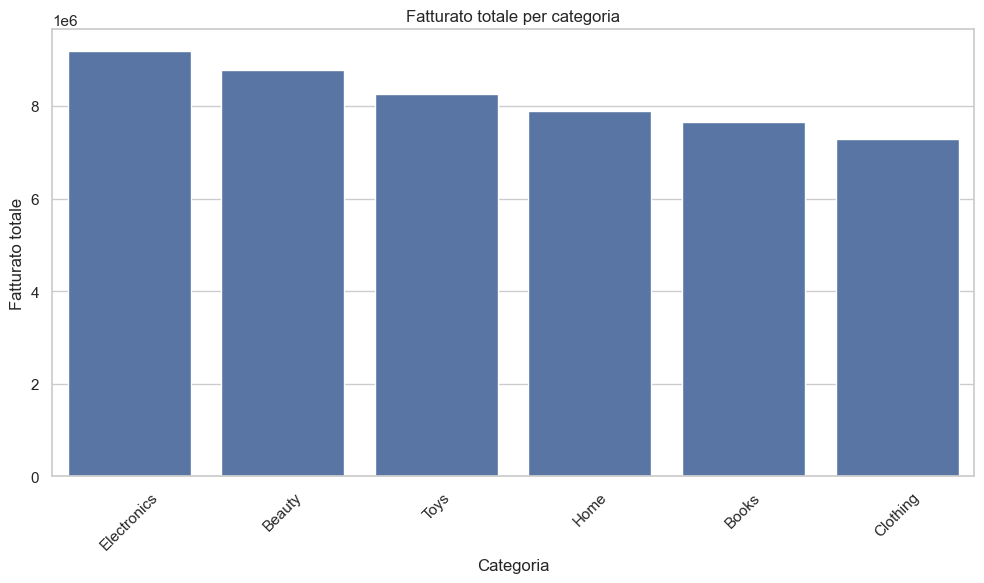

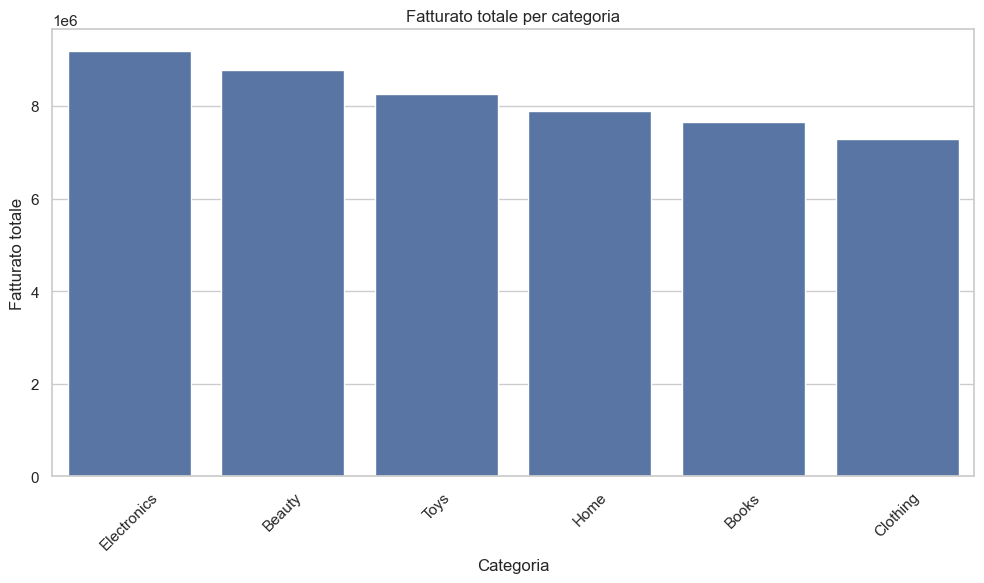

Grafico salvato come: fatturato_per_categoria.png


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=revenue_by_category_pd,
    x="category",
    y="total_revenue"
)

plt.title("Fatturato totale per categoria")
plt.xlabel("Categoria")
plt.ylabel("Fatturato totale")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

output_chart_path = "fatturato_per_categoria.png"

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(
    data=revenue_by_category_pd,
    x="category",
    y="total_revenue"
)

plt.title("Fatturato totale per categoria")
plt.xlabel("Categoria")
plt.ylabel("Fatturato totale")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Grafico salvato come: {output_chart_path}")

In [ ]:
query.awaitTermination()